# Importation

In [1]:
# LES ALGORITHMES
# Pour StableBaselines
from QLearning import *
from DQN import *
from PPO import *
from helperPlot import *

# Pour RLLib
from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from ray import train, tune
from rllib_helper import *

# Aide
import time
from pprint import pprint

# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

# Environnements

Ce premier labyrinthe ne donne qu'une unique récompense en cas de sortie de l'agent du labyrinthe.

In [2]:
class FrozenLakeEnv(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLakeEnv, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.width * self.height)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        return self.state, {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = 0
        else :
            reward = 0
        return self.state, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x
    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Le second environnement ajoute les récompenses négatives à chaque pas et à chaque fois que l'agent tombe dans un trou.

In [3]:
class FrozenLake2Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake2Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.width * self.height)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        return self.state, {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)
        return self.state, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x
    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

# Entraînement du DQN de RLlib sur labyrinthe env 1

In [4]:
config = (
    DQNConfig()
    .environment(
        FrozenLakeEnv,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [40000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[8], [32], [128], [16, 16], [64, 64]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-16 14:50:44,710	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=34775) 2025-06-16 14:50:50,194	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=34775) 2025-06-16 14:50:50,881	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `

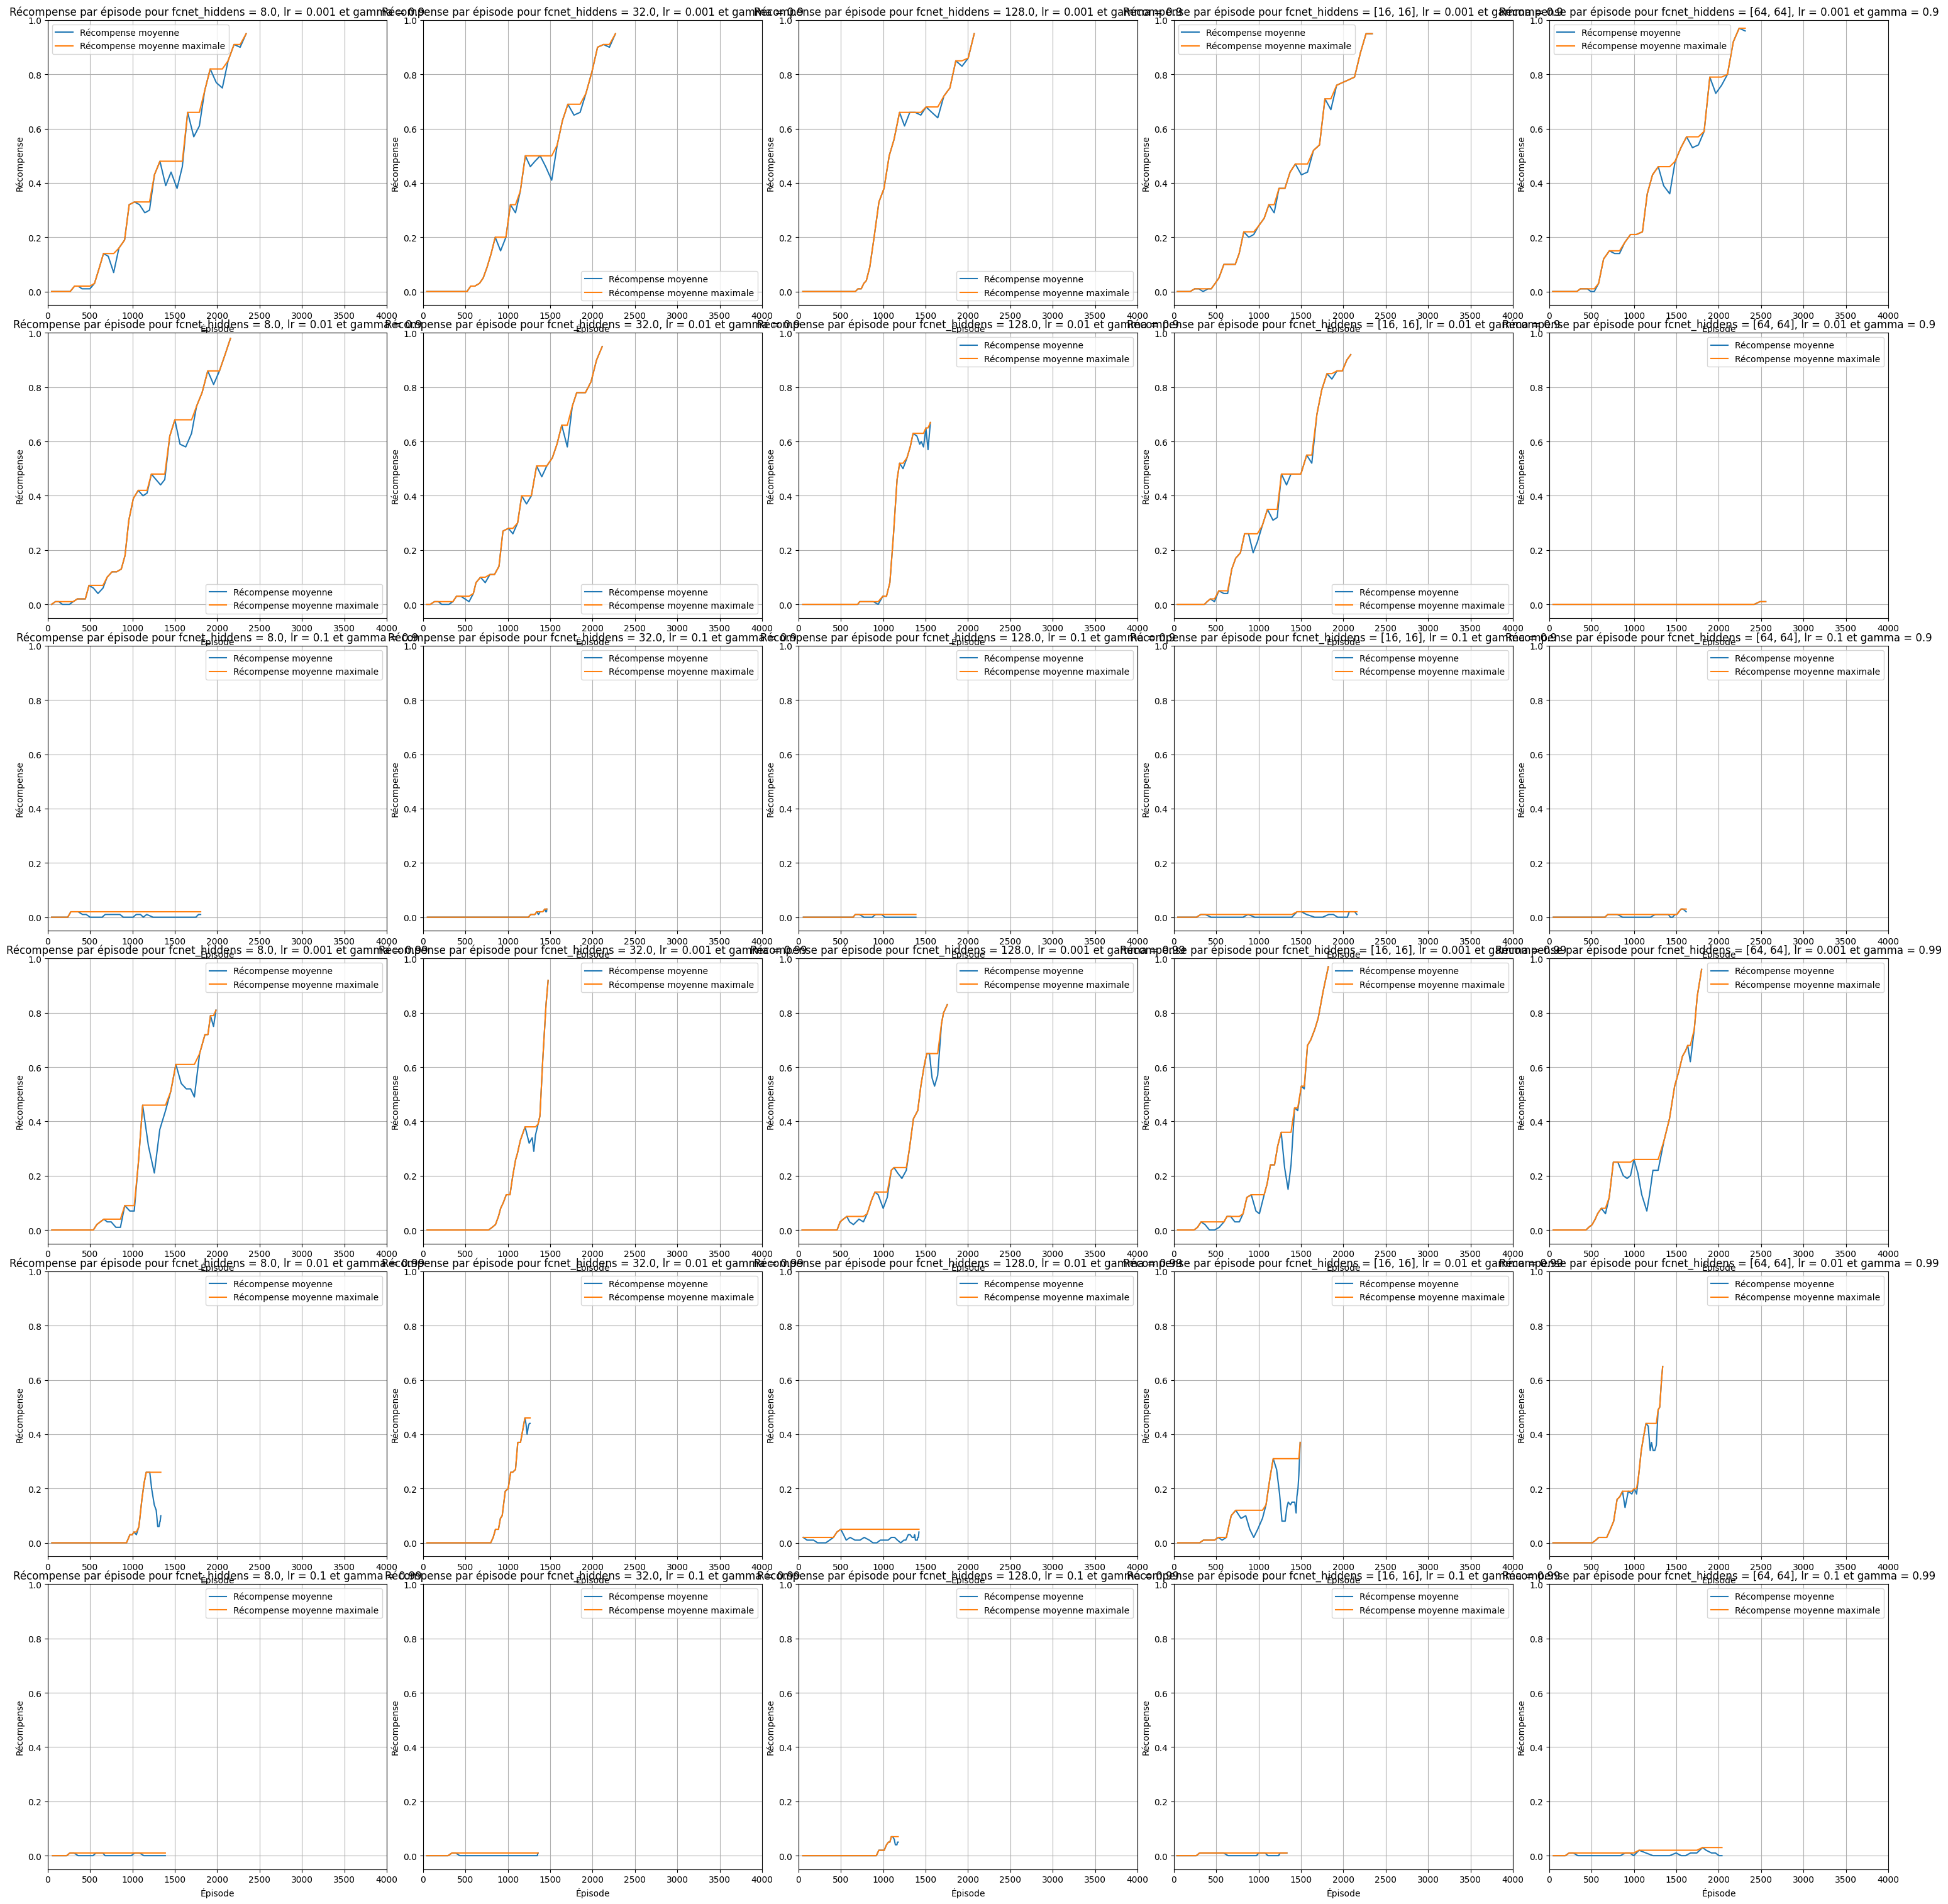

In [13]:
comparison_plot_3(results,
                  "fcnet_hiddens", [8., 32., 128., [16, 16], [64, 64]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -0.05, 1
                 )

Sans surprise on remarque qu'aucun résultat n'est satisfaisant.
En effet, le comportement du DQN de RLlib est semblable à celui de StableBaselines.

Le problème provient de l'environnement, quelque soit l'implémentation de l'algorithme nous aurons toujours le même soucis.

# DQN pour environnement 2

In [4]:
config = (
    DQNConfig()
    .environment(
        FrozenLake2Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [40000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[8], [32], [128], [16, 16], [64, 64]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 30000},
    ),
)
results = tuner.fit()

2025-06-16 16:41:48,561	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=46475) 2025-06-16 16:41:53,849	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=46475) 2025-06-16 16:41:54,537	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `

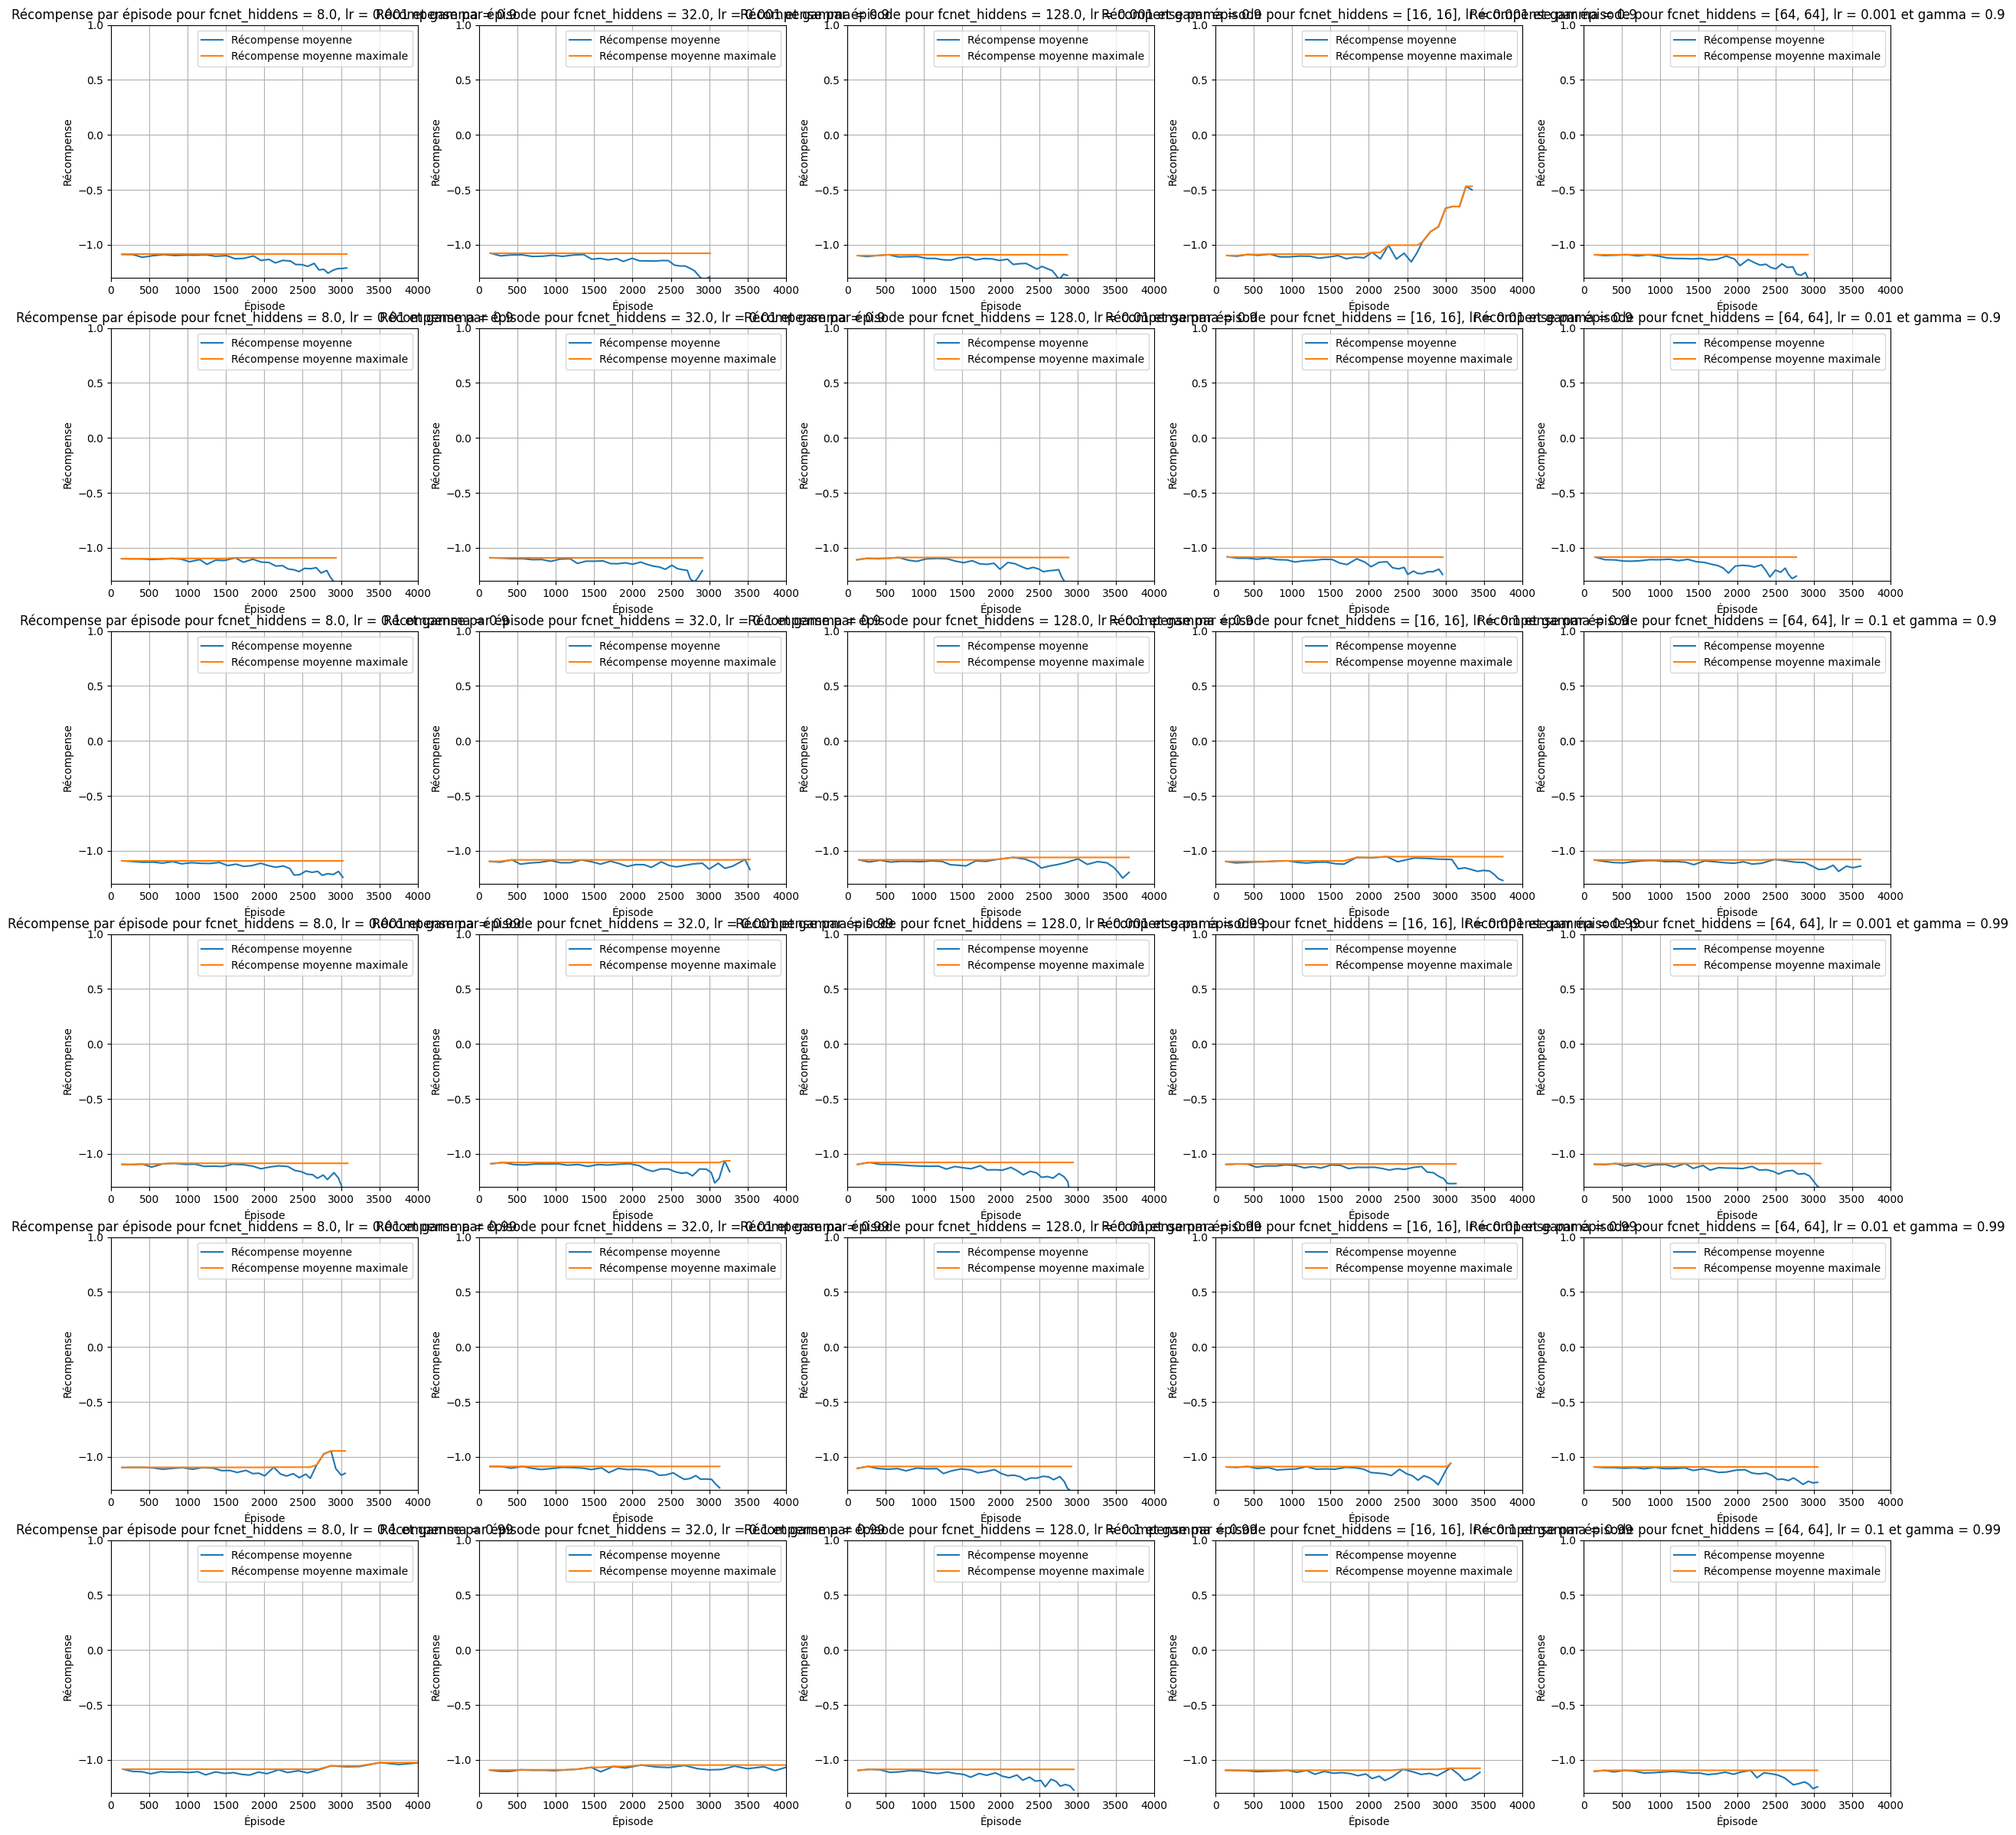

In [7]:
comparison_plot_3(results,
                  "fcnet_hiddens", [8., 32., 128., [16, 16], [64, 64]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -1.3, 1
                 )